# Parallel Computing with JAX for Earth Scientists

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chrism0dwk/colab/blob/master/parallel-programming-with-jax/parallel_computing_with_jax.ipynb)

This worksheet is a hands-on tour of how [JAX](https://github.com/google/jax) helps you write
**parallel, hardware-accelerated** scientific code — usually with only small changes to
ordinary NumPy-style code.

We'll build up through four problems that look like the kind of work computational earth
scientists actually do:

1. **Warm-up:** `jit` on a single grid calculation (why compiling helps)
2. **Ensemble parameter sweeps** with `vmap` — run a model under hundreds of parameter
   sets *simultaneously*, instead of looping over them
3. **A 2D diffusion model** (heat / pollutant spreading in a river) using `lax.scan` + `jit`
4. **Monte Carlo particle transport** (sediment / pollutant dispersal) — an "embarrassingly
   parallel" problem, perfect for `vmap` + `jax.random`

There's also an optional Section 5 on automatic differentiation (fitting a model to data)
and an optional capstone on `pmap` for multi-device parallelism.

**How to use this notebook:** each section has a worked example, followed by an
**Exercise** cell with a `# TODO` for you to fill in. Solutions are in the final
section — try not to peek until you've had a go!

> Runtime tip: In Colab, go to `Runtime > Change runtime type` and select a **GPU** (T4 is
> fine) to see the biggest speedups in Sections 2-4. Everything will still run on CPU, just
> with smaller (or sometimes no) speedups.


In [2]:
#@title Setup: install and import JAX
#!pip install -q --upgrade jax jax[cuda12] 2>/dev/null || pip install -q --upgrade jax

import jax
import jax.numpy as jnp
import numpy as np
import time
import matplotlib.pyplot as plt

print("JAX version:", jax.__version__)
print("Devices JAX can see:", jax.devices())


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX version: 0.11.1
Devices JAX can see: [CpuDevice(id=0)]


If the cell above lists a `TpuDevice`/`GpuDevice`, great — you've got hardware
acceleration. If it only lists `CpuDevice`, everything below still works, you'll just see
smaller speedup numbers.


---
## Section 1 — Warm-up: what does `jit` actually buy you?

Before we talk about *parallel* computing, we need the single most important JAX concept:
**`jax.jit`**.

Ordinary JAX code (like ordinary NumPy code) runs one operation at a time: Python calls into
XLA, gets a result back, then calls the next operation. Each of those "hops" between Python
and the accelerator costs time — even if the actual math is fast.

`jax.jit` traces your function once, hands the *whole computation* to XLA as a single
compiled program, and lets XLA fuse and optimize it. No more per-operation overhead, and
XLA can parallelize the fused operations across all the cores/lanes of your GPU/TPU/CPU.

Let's see this on a toy "vegetation index correction" calculation applied to a big grid of
pixel values.


In [3]:
def spectral_correction(x):
    """A stand-in for a per-pixel spectral correction (e.g. NDVI-style),
    repeated a few times to give jit something to optimize."""
    for _ in range(10):
        x = jnp.sin(x) * jnp.cos(x) + jnp.exp(-x**2)
    return x

fast_correction = jax.jit(spectral_correction)

# A "satellite image": 1000 x 1000 grid of pixel reflectance values
x = jnp.ones((1000, 1000))

# Warm-up call: this is where tracing + compilation happens (slow, one-time cost)
fast_correction(x).block_until_ready()

# Time the non-jitted version
start = time.time()
for _ in range(20):
    spectral_correction(x).block_until_ready()
no_jit_time = time.time() - start

# Time the jitted version
start = time.time()
for _ in range(20):
    fast_correction(x).block_until_ready()
jit_time = time.time() - start

print(f"Without jit: {no_jit_time:.4f}s")
print(f"With jit:    {jit_time:.4f}s")
print(f"Speedup:     {no_jit_time / jit_time:.1f}x")


Without jit: 1.7242s
With jit:    0.2289s
Speedup:     7.5x


> **Note**  we use `.block_until_ready()` when we time JAX functions.  This is because JAX is _asynchronous_ -- functions return immediately, while computation happens in the background.  Thus your program only waits for computation to end at the point that a result is used.  Since we don't use the result here, we call the `.block_until_ready()` method to force JAX into a _synchronous_ computation mode.

**Discussion questions:**
- Why did we call `fast_correction` once *before* timing it?
- What do you think would happen to the speedup if the grid were only 10x10 instead of
  1000x1000? Try it.

### Exercise 1
Modify `spectral_correction` to operate on a grid that's `(5000, 5000)` instead of
`(1000, 1000)`. Does the speedup from `jit` get bigger or smaller? Why do you think that is?


In [4]:
# TODO: Exercise 1
# 1. Create a new array `x_big` of shape (5000, 5000)
# 2. Re-run the warm-up + timing comparison above using x_big
# 3. Print the new speedup and compare it to the one above

# Your code here


---
## Section 2 — Ensemble parameter sweeps with `vmap`

A very common earth-science task: run the *same* model many times with different parameter
values (an ensemble), e.g. to explore uncertainty or calibrate against observations.

The naive way is a Python `for` loop over parameter sets. `jax.vmap` instead
**vectorizes the model automatically** — it transforms a function written for a *single*
set of inputs into one that runs on a whole *batch* of inputs, in parallel, with no
loop and (often) no code changes to the model itself.

Let's use a simple permafrost active-layer thaw model: a Stefan-type equation estimating
thaw depth $m(t)$ over a melt season as a function of a "thermal parameter" $k$ (bundling soil
thermal conductivity, latent heat, etc.) and cumulative degree-days of thawing $S(t)$:

$$
m(t) = k\sqrt(S(t))
$$

We'll treat this as our toy "model" and sweep over many values of $k$ to see how sensitive
thaw depth is to soil thermal properties.


In [6]:
def thaw_depth_model(k, days=jnp.arange(1, 121, dtype=jnp.float32)):
    """Estimate thaw depth (m(t)) over t=`days` days of a melt season for
    thermal parameter k, using a simple Stefan-type approximation.
    Assumes a constant +1 degree-day accumulation per day for simplicity."""
    cumulative_degree_days = jnp.cumsum(jnp.ones_like(days))
    return k * jnp.sqrt(cumulative_degree_days) / 100.0  # scaled to metres

# One ensemble member, run the ordinary way:
k_example = 3.5
depths_example = thaw_depth_model(k_example)
print(depths_example[:5], "...")


[0.035      0.04949747 0.06062178 0.07       0.07826238] ...


In [8]:
# Now sweep over many values of k using a Python loop (the "slow" way)
k_values = jnp.linspace(1.0, 10.0, 2000)  # 2000 ensemble members

start = time.time()
results_loop = jnp.stack([thaw_depth_model(k) for k in k_values]) # loop expressed as list comprehension
results_loop.block_until_ready()
loop_time = time.time() - start
print(f"Python loop over {len(k_values)} ensemble members: {loop_time:.4f}s")


Python loop over 2000 ensemble members: 0.3692s


In [9]:
# The vmap way: vectorize thaw_depth_model over its first argument (k)
batched_thaw_model = jax.jit(jax.vmap(thaw_depth_model, in_axes=(0, None)))

days = jnp.arange(1, 121, dtype=jnp.float32)

# Warm-up
batched_thaw_model(k_values, days).block_until_ready()

start = time.time()
results_vmap = batched_thaw_model(k_values, days)
results_vmap.block_until_ready()
vmap_time = time.time() - start
print(f"vmap + jit over {len(k_values)} ensemble members: {vmap_time:.4f}s")
print(f"Speedup: {loop_time / vmap_time:.1f}x")

# Sanity check: results should match
print("Results match:", jnp.allclose(results_loop, results_vmap, atol=1e-4))


vmap + jit over 2000 ensemble members: 0.0003s
Speedup: 1459.3x
Results match: True


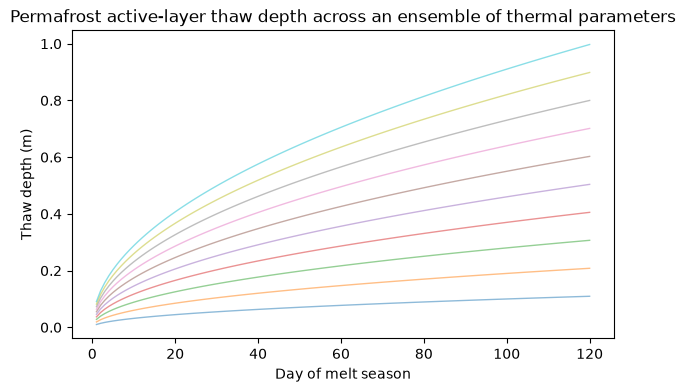

In [10]:
# Visualize the ensemble spread
plt.figure(figsize=(7, 4))
for i in range(0, len(k_values), 200):
    plt.plot(days, results_vmap[i], alpha=0.5, lw=1)
plt.xlabel("Day of melt season")
plt.ylabel("Thaw depth (m)")
plt.title("Permafrost active-layer thaw depth across an ensemble of thermal parameters")
plt.show()


**Note the pattern:** `in_axes=(0, None)` tells `vmap` "batch over axis 0 of the first
argument (`k`), but don't batch the second argument (`days`) — broadcast it to every
ensemble member." This `in_axes` argument is the main thing you'll need to think about
when using `vmap`.

### Exercise 2
Real thaw models usually also vary with a second parameter — let's add a "melt season
start offset" $t0$ (in days) that shifts when thawing begins, so:

$$
m(t) = k * \sqrt{max(S(t) - t_0, 0)}
$$

Modify `thaw_depth_model` to accept both $k$ and $t_0$, then use `vmap` with **two** batched
axes to sweep over a 2D grid of $(k, t_0)$ combinations (hint: you can nest two `vmap` calls,
one for each parameter, or use `in_axes=(0, 0)` with two arrays of matching length —
try the nested version first, it's a good way to see how `vmap` composes).


In [11]:
# TODO: Exercise 2
# 1. Write thaw_depth_model_v2(k, t0, days) implementing the formula above
#    (use jnp.clip or jnp.maximum to avoid sqrt of a negative number)
# 2. Create k_values (e.g. 50 values) and t0_values (e.g. 50 values)
# 3. Use nested vmap: first vmap over t0 (in_axes=(None, 0, None)),
#    then vmap the result over k (in_axes=(0, None, None))
# 4. jit the whole thing and confirm the output shape is (len(k_values), len(t0_values), len(days))

# Your code here


---
## Section 3 — A 2D diffusion model: heat/pollutant spreading in a river

Now let's parallelize *within* a single simulation, rather than across an ensemble.

We'll simulate a pollutant (or heat) plume diffusing across a 2D grid representing a cross
section of a river, using the classic explicit finite-difference update for the diffusion
equation:

$$
C_{i,j}(t+\mathrm{d}t) = C_{i,j}(t) + D\mathrm{d}t\nabla^2C_{i,j}
$$

This requires **many sequential time steps**, each of which updates **every grid cell in
parallel**. This is a great example of JAX's two complementary kinds of "parallel":
- *spatial* parallelism: one `jnp` array operation updates the whole grid at once (no
  Python loop over grid cells — this is already implicit in array programming, but `jit`
  is what makes it *fast*)
- efficient *sequential* stepping: `jax.lax.scan` replaces a slow Python `for` loop over
  time steps with a compiled loop that XLA can optimize as a single unit


In [13]:
def laplacian(C):
    """5-point stencil Laplacian with zero-flux (reflective) boundaries."""
    C_up    = jnp.pad(C[:-1, :], ((1, 0), (0, 0)), mode="edge")
    C_down  = jnp.pad(C[1:, :],  ((0, 1), (0, 0)), mode="edge")
    C_left  = jnp.pad(C[:, :-1], ((0, 0), (1, 0)), mode="edge")
    C_right = jnp.pad(C[:, 1:],  ((0, 0), (0, 1)), mode="edge")
    return C_up + C_down + C_left + C_right - 4 * C

def diffusion_step(C, _, D=0.2, dt=1.0):
    return C + D * dt * laplacian(C), None

def run_diffusion(C0, n_steps, D=0.2, dt=1.0):
    step_fn = lambda C, _: diffusion_step(C, _, D=D, dt=dt)
    C_final, _ = jax.lax.scan(step_fn, C0, xs=None, length=n_steps)
    return C_final

run_diffusion_jit = jax.jit(run_diffusion, static_argnames=("n_steps",))


In [14]:
# Set up initial condition: a pollutant spill at one point in a 100x100 river cross-section grid
grid_size = 100
C0 = jnp.zeros((grid_size, grid_size))
C0 = C0.at[grid_size // 2, grid_size // 4].set(1000.0)  # spill point

n_steps = 2000

# Warm-up / compile
run_diffusion_jit(C0, n_steps).block_until_ready()

start = time.time()
C_final = run_diffusion_jit(C0, n_steps)
C_final.block_until_ready()
scan_time = time.time() - start
print(f"lax.scan + jit, {n_steps} steps: {scan_time:.4f}s")


lax.scan + jit, 2000 steps: 0.0164s


In [15]:
# Compare to a plain Python for-loop over time steps (no scan, no jit)
def run_diffusion_pyloop(C0, n_steps, D=0.2, dt=1.0):
    C = C0
    for _ in range(n_steps):
        C = C + D * dt * laplacian(C)
    return C

start = time.time()
C_final_loop = run_diffusion_pyloop(C0, n_steps)
C_final_loop.block_until_ready()
loop_time = time.time() - start
print(f"Python for-loop, {n_steps} steps: {loop_time:.4f}s")
print(f"Speedup: {loop_time / scan_time:.1f}x")
print("Results match:", jnp.allclose(C_final, C_final_loop, atol=1e-3))


Python for-loop, 2000 steps: 1.4939s
Speedup: 91.0x
Results match: True


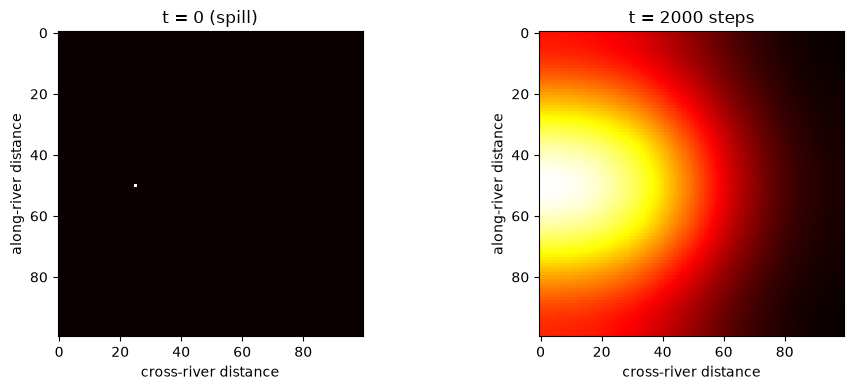

In [16]:
# Visualize the plume before and after diffusion
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(C0, cmap="hot")
axes[0].set_title("t = 0 (spill)")
axes[1].imshow(C_final, cmap="hot")
axes[1].set_title(f"t = {n_steps} steps")
for ax in axes:
    ax.set_xlabel("cross-river distance")
    ax.set_ylabel("along-river distance")
plt.tight_layout()
plt.show()


**Discussion:** `lax.scan` is JAX's way of expressing "do this fixed number of times,
carrying state forward" so that XLA can compile the *entire* time-stepping loop, not just
one step. This matters a lot for diffusion/advection models with thousands of time steps.

### Exercise 3
Add a simple **source term** representing a river discharging a constant amount of
pollutant at the spill cell every time step (rather than one instantaneous spill), and
re-run the simulation. Does the model reach a steady state? Try plotting the *total* mass
in the grid (`C.sum()`) over time — you'll need to have `lax.scan` return `C.sum()` at
each step in its second output (the "`ys`" output) rather than `None`.


In [17]:
# TODO: Exercise 3
# 1. Modify diffusion_step to add a fixed source (e.g. +50.0) to a chosen cell every step
# 2. Modify the scan step function to return C.sum() as the second element of the tuple
#    instead of None, so lax.scan collects a time series of total mass
# 3. Run for n_steps and plot total mass vs. time step

# Your code here


---
## Section 4 — Monte Carlo particle transport (embarrassingly parallel)

Sediment grains, pollutant parcels, or drifting buoys are often modeled as many independent
particles moving through a velocity field with some random turbulent motion. Because each
particle's trajectory doesn't depend on any other particle, this is a textbook
**embarrassingly parallel** problem — a perfect match for `vmap`.

We'll simulate particles advected by a simple steady flow field plus random turbulent
"jitter" (a basic random walk on top of advection).


In [18]:
def velocity_field(pos):
    """A simple steady flow: faster in the center of the channel, slower near the banks
    (like a river cross-section), flowing in +x."""
    x, y = pos
    u = 1.0 - (y - 0.5) ** 2 * 4.0  # parabolic profile, max at y=0.5
    v = 0.0
    return jnp.array([u, v])

def advect_particle(key, pos0, n_steps=200, dt=0.05, turbulence=0.05):
    """Advect a single particle forward n_steps under the flow field plus random jitter."""
    def step(carry, _):
        pos, key = carry
        key, subkey = jax.random.split(key)
        vel = velocity_field(pos)
        noise = jax.random.normal(subkey, shape=(2,)) * turbulence
        pos_new = pos + dt * vel + jnp.sqrt(dt) * noise
        pos_new = pos_new.at[1].set(jnp.clip(pos_new[1], 0.0, 1.0))  # stay in channel
        return (pos_new, key), pos_new

    (pos_final, _), trajectory = jax.lax.scan(step, (pos0, key), xs=None, length=n_steps)
    return trajectory


In [19]:
n_particles = 5000
key = jax.random.PRNGKey(0)
keys = jax.random.split(key, n_particles)

# All particles start at the same upstream location, spread across the channel width
y0 = jnp.linspace(0.05, 0.95, n_particles)
pos0 = jnp.stack([jnp.zeros(n_particles), y0], axis=1)

# vmap over particles: batch the key and starting position, keep n_steps/dt/turbulence fixed
advect_all = jax.jit(
    jax.vmap(advect_particle, in_axes=(0, 0, None, None, None)),
    static_argnames=("n_steps",),
)

# Warm-up
advect_all(keys, pos0, 200, 0.05, 0.05).block_until_ready()

start = time.time()
trajectories = advect_all(keys, pos0, 200, 0.05, 0.05)
trajectories.block_until_ready()
vmap_time = time.time() - start
print(f"vmap over {n_particles} particles: {vmap_time:.4f}s")
print("Trajectories shape (particles, timesteps, xy):", trajectories.shape)


vmap over 5000 particles: 0.1388s
Trajectories shape (particles, timesteps, xy): (5000, 200, 2)


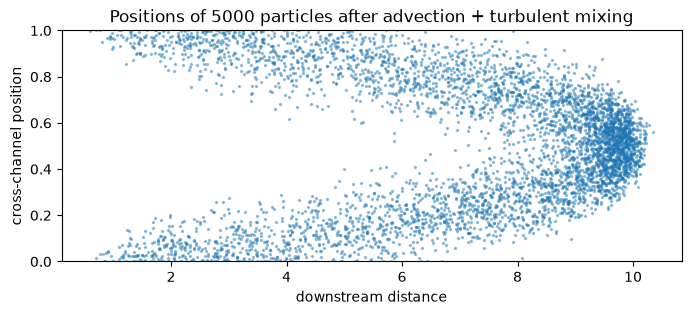

In [20]:
# Visualize final particle positions (a proxy for a plume of suspended sediment)
final_positions = trajectories[:, -1, :]

plt.figure(figsize=(8, 3))
plt.scatter(final_positions[:, 0], final_positions[:, 1], s=2, alpha=0.4)
plt.xlabel("downstream distance")
plt.ylabel("cross-channel position")
plt.title(f"Positions of {n_particles} particles after advection + turbulent mixing")
plt.ylim(0, 1)
plt.show()


**Discussion:** notice we didn't write a single explicit parallel loop — `vmap` took a
function written for *one* particle and ran it, unmodified, over thousands of particles at
once. This "write it for one, `vmap` it for many" pattern is one of the most useful habits
to build with JAX.

### Exercise 4
Compare the `vmap` version's runtime against a plain Python loop over particles (calling
`advect_particle` once per particle and stacking the results). Try `n_particles = 500` and
`n_particles = 5000` — how does the *speedup* change as the ensemble grows? What does this
tell you about when vectorization is worth the effort?


In [ ]:
# TODO: Exercise 4
# 1. Write a Python for-loop version that calls advect_particle once per particle
# 2. Time it for n_particles = 500 and n_particles = 5000
# 3. Compare against the vmap timings above and compute the speedup in each case
# 4. In a markdown cell (or a comment), briefly note what you observe

# Your code here


---
## Section 5 (optional) — Bonus: why JAX, not just "fast NumPy"?

`jit` and `vmap` give you speed and parallelism, but JAX's other superpower is
**automatic differentiation** (`jax.grad`), which is central to a lot of earth-science
inverse problems: given observations, find the model parameters that best explain them.

Let's fit the diffusion coefficient `D` from Section 3 to some (synthetic) noisy
observations of the plume, using gradient descent — powered by `jax.grad`.


In [ ]:
# Generate synthetic "observed" data using a known true D
D_true = 0.35
C0_obs = jnp.zeros((grid_size, grid_size)).at[grid_size // 2, grid_size // 4].set(1000.0)
C_observed = run_diffusion(C0_obs, n_steps=500, D=D_true)
key = jax.random.PRNGKey(1)
C_observed = C_observed + jax.random.normal(key, C_observed.shape) * 2.0  # add noise

def loss_fn(D, C0, C_target, n_steps=500):
    C_pred = run_diffusion(C0, n_steps=n_steps, D=D)
    return jnp.mean((C_pred - C_target) ** 2)

grad_loss = jax.jit(jax.grad(loss_fn), static_argnames=("n_steps",))
loss_jit = jax.jit(loss_fn, static_argnames=("n_steps",))

# Gradient descent to recover D
D_estimate = 0.1  # initial guess
learning_rate = 0.5

history = []
for i in range(40):
    g = grad_loss(D_estimate, C0_obs, C_observed, n_steps=500)
    D_estimate = D_estimate - learning_rate * g
    history.append(float(D_estimate))
    if i % 10 == 0:
        print(f"step {i:3d}: D_estimate = {D_estimate:.4f}, loss = {loss_jit(D_estimate, C0_obs, C_observed, n_steps=500):.4f}")

print(f"\nTrue D:      {D_true}")
print(f"Recovered D: {D_estimate:.4f}")


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history, label="D estimate")
plt.axhline(D_true, color="red", linestyle="--", label="True D")
plt.xlabel("Gradient descent step")
plt.ylabel("D")
plt.legend()
plt.title("Recovering the diffusion coefficient via jax.grad")
plt.show()


No finite-difference gradient approximation, no hand-derived adjoint model — `jax.grad`
differentiated straight through the `lax.scan` time-stepping loop automatically. This is
the same mechanism used to train neural networks, but here we're using it to calibrate a
physical model, which is exactly the kind of thing JAX is increasingly used for in the
earth sciences (e.g. differentiable hydrology and climate models).


---
## Section 6 (optional capstone) — Multi-device parallelism with `pmap`

`vmap` parallelizes *within* a single device (e.g., across the cores/lanes of one GPU).
For truly large ensembles, you may want to split work **across multiple devices** —
multiple GPUs/TPUs, or multiple nodes of a cluster. That's what `jax.pmap` is for.

Colab typically only gives you one accelerator, so to see `pmap` in action, we can force
JAX to *pretend* the CPU has several devices. This won't be *faster* (they're not really
separate hardware), but it lets you see exactly how you'd structure code for a real
multi-GPU cluster, e.g. one running a regional climate ensemble across many nodes.

**Reset the Colab runtime type to CPU (device count simulation only works cleanly on CPU).  Then restart the Colab runtime (Runtime -> Restart session) first.  Then run the cell below BEFORE any other JAX code** .


In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"

# NOTE: if you already imported/ran JAX above, you must restart the Colab runtime
# (Runtime > Restart runtime) and re-run this cell FIRST for it to take effect.
import jax
print("Simulated devices:", jax.devices())
print("Device count:", jax.device_count())


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Simulated devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
Device count: 8


In [2]:
import jax.numpy as jnp

def ensemble_member_summary(k):
    """Pretend this is an expensive per-ensemble-member simulation (reuse Section 2's model)."""
    days = jnp.arange(1, 121, dtype=jnp.float32)
    cumulative_degree_days = jnp.cumsum(jnp.ones_like(days))
    depth = k * jnp.sqrt(cumulative_degree_days) / 100.0
    return depth[-1]  # final thaw depth

n_devices = jax.device_count()
k_values_pmap = jnp.linspace(1.0, 10.0, n_devices)  # one ensemble member per "device"

# pmap distributes the first axis of its input across available devices
distributed_results = jax.pmap(ensemble_member_summary)(k_values_pmap)
print("k values:      ", k_values_pmap)
print("Final depths:  ", distributed_results)


k values:       [ 1.         2.2857144  3.5714288  4.857143   6.142857   7.4285717
  8.714286  10.       ]
Final depths:   [0.10954452 0.25038746 0.39123043 0.5320734  0.6729163  0.81375927
 0.9546022  1.0954452 ]


**Discussion:** in a real HPC/cloud setting with actual multiple GPUs or TPU pods, this
exact `pmap` pattern is how you'd spread a large ensemble across hardware — each device
gets one slice of the leading array axis and runs independently, then results are gathered
back together. For within-device parallelism (as in Sections 2-4), `vmap` is usually what
you want; reach for `pmap` (or the more modern `jax.sharding` / `shard_map` APIs) when you
have more than one physical device to spread work across.


---
## Summary

| Tool | What it parallelizes | Used for |
|---|---|---|
| `jax.jit` | Fuses a whole computation into one compiled program | Removing per-op dispatch overhead (Section 1) |
| `jax.vmap` | Vectorizes a function over a batch dimension, within one device | Ensemble sweeps, many independent particles (Sections 2, 4) |
| `jax.lax.scan` | Compiles a sequential loop as a single unit | Efficient time-stepping (Section 3) |
| `jax.grad` | Automatic differentiation through your model | Calibration / inverse problems (Section 5) |
| `jax.pmap` / sharding | Spreads work across multiple physical devices | Large-scale ensembles on clusters (Section 6) |

A good rule of thumb: **write your model for a single instance (one grid, one particle, one
parameter set) in plain JAX/NumPy style, then reach for `vmap`/`pmap` to parallelize over
many instances, and `jit` to make the whole thing fast.**
